# Exploratory Data Analysis (EDA)

Este notebook contiene una estructura completa para realizar un análisis exploratorio de datos.

## Objetivos
- Comprender la estructura del dataset.
- Evaluar la calidad de los datos.
- Analizar variables numéricas y categóricas.
- Detectar valores nulos, duplicados y posibles outliers.
- Explorar relaciones entre variables.
- Documentar los principales hallazgos.

In [18]:
%pip install matplotlib seaborn pandas numpy openpyxl scipy


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Importación de librerías

In [19]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid')

print('Librerías cargadas correctamente.')

Matplotlib is building the font cache; this may take a moment.


Librerías cargadas correctamente.


## 2. Carga del dataset

Modifica `DATA_PATH` con la ubicación de tu archivo. El notebook soporta CSV, Excel y Parquet.

In [20]:
DATA_PATH = Path('/Users/vivi/habi-test/habi-test/fuentes/co_transacciones_habi.csv')

def load_dataset(path: Path) -> pd.DataFrame:
    """Carga un dataset según su extensión."""
    if not path.exists():
        raise FileNotFoundError(
            f'No se encontró el archivo: {path.resolve()}\n'
            'Actualiza la variable DATA_PATH con la ruta correcta.'
        )

    extension = path.suffix.lower()

    if extension == '.csv':
        return pd.read_csv(path)
    if extension in {'.xlsx', '.xls'}:
        return pd.read_excel(path)
    if extension == '.parquet':
        return pd.read_parquet(path)

    raise ValueError(f'Formato no soportado: {extension}')

# Descomenta la siguiente línea cuando hayas configurado la ruta:
df = load_dataset(DATA_PATH)

df.head()

,id,ciudad,tipo,area_m2,alcobas,banos,precio_cop,lat,lon,fecha,estado
0,CO038760,MEDELLIN,Casa,109.60,2,3,"216,700,000.00",6.24,-75.55,2024-02-28,publicada
1,CO043235,BOGOTA,Casa,128.70,3,2,"247,600,000.00",4.59,-74.04,2024-06-22,vendida
2,CO004450,MEDELLIN,Casa,176.70,2,2,"200,000,000.00",6.20,-75.56,2024-04-10,comprada
3,CO025197,BOGOTA,Apartamento,77.80,2,2,"159,700,000.00",4.66,-74.05,2024-10-11,publicada
4,CO031499,Bogota,Apartamento,84.90,2,2,"165,800,000.00",4.66,-74.12,2024-03-21,comprada


## 3. Vista general del dataset

In [21]:
print(f'Filas: {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]:,}')
print('\nNombres de columnas:')
display(pd.DataFrame({'column': df.columns}))

display(df.head())

Filas: 45,900
Columnas: 11

Nombres de columnas:


,column
0,id
1,ciudad
2,tipo
3,area_m2
4,alcobas
5,banos
6,precio_cop
7,lat
8,lon
9,fecha


,id,ciudad,tipo,area_m2,alcobas,banos,precio_cop,lat,lon,fecha,estado
0,CO038760,MEDELLIN,Casa,109.60,2,3,"216,700,000.00",6.24,-75.55,2024-02-28,publicada
1,CO043235,BOGOTA,Casa,128.70,3,2,"247,600,000.00",4.59,-74.04,2024-06-22,vendida
2,CO004450,MEDELLIN,Casa,176.70,2,2,"200,000,000.00",6.20,-75.56,2024-04-10,comprada
3,CO025197,BOGOTA,Apartamento,77.80,2,2,"159,700,000.00",4.66,-74.05,2024-10-11,publicada
4,CO031499,Bogota,Apartamento,84.90,2,2,"165,800,000.00",4.66,-74.12,2024-03-21,comprada


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45900 entries, 0 to 45899
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          45900 non-null  object 
 1   ciudad      45900 non-null  object 
 2   tipo        45900 non-null  object 
 3   area_m2     45900 non-null  float64
 4   alcobas     45900 non-null  int64  
 5   banos       45900 non-null  int64  
 6   precio_cop  45533 non-null  float64
 7   lat         45900 non-null  float64
 8   lon         45900 non-null  float64
 9   fecha       45900 non-null  object 
 10  estado      45900 non-null  object 
dtypes: float64(4), int64(2), object(5)
memory usage: 3.9+ MB


## 4. Resumen estadístico

In [23]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,45900,45000,CO016539,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ciudad,45900,11,Santiago de Cali,5752,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo,45900,4,Apartaestudio,11578,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_m2,"45,900.00",NaN,NaN,NaN,120.38,41.51,28.00,91.70,120.40,148.60,305.50
alcobas,"45,900.00",NaN,NaN,NaN,2.50,0.96,1.00,2.00,2.50,3.00,4.00
banos,"45,900.00",NaN,NaN,NaN,1.80,0.75,1.00,1.00,2.00,2.00,3.00
precio_cop,"45,533.00",NaN,NaN,NaN,"167,288,309.98","72,971,146.22",60.00,"116,000,000.00","160,500,000.00","211,600,000.00","567,800,000.00"
lat,"45,900.00",NaN,NaN,NaN,6.33,2.86,3.37,4.58,4.72,6.31,11.05
lon,"45,900.00",NaN,NaN,NaN,-75.24,0.90,-76.59,-75.64,-74.87,-74.17,-74.03
fecha,45900,336,2024-08-05,177,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Calidad de los datos

In [24]:
quality_summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null_count': df.notna().sum(),
    'null_count': df.isna().sum(),
    'null_percentage': (df.isna().mean() * 100).round(2),
    'unique_values': df.nunique(dropna=False)
}).sort_values('null_percentage', ascending=False)

display(quality_summary)

,dtype,non_null_count,null_count,null_percentage,unique_values
precio_cop,float64,45533,367,0.80,3889
id,object,45900,0,0.00,45000
ciudad,object,45900,0,0.00,11
tipo,object,45900,0,0.00,4
area_m2,float64,45900,0,0.00,2147
alcobas,int64,45900,0,0.00,4
banos,int64,45900,0,0.00,3
lat,float64,45900,0,0.00,43209
lon,float64,45900,0,0.00,43284
fecha,object,45900,0,0.00,336


In [25]:
duplicate_count = df.duplicated().sum()
print(f'Registros duplicados: {duplicate_count:,}')

Registros duplicados: 900


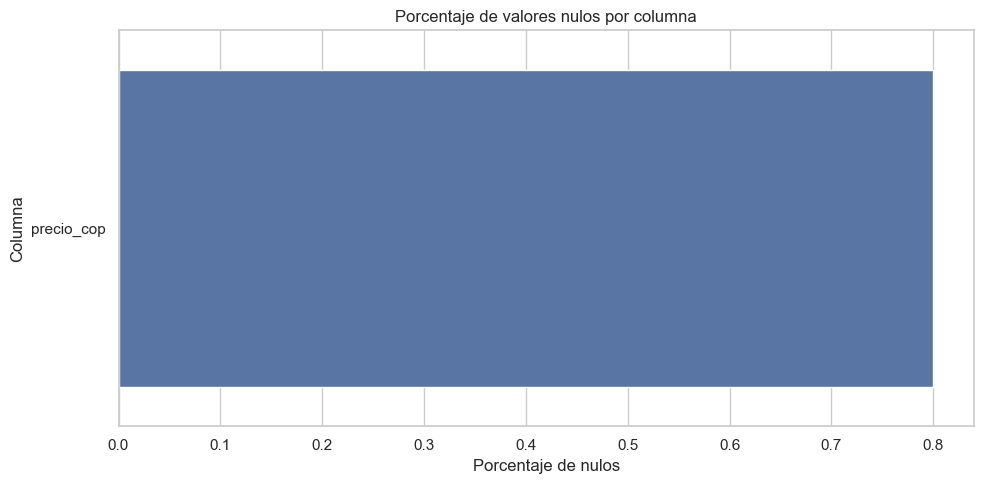

In [26]:
missing = quality_summary[quality_summary['null_count'] > 0]

if missing.empty:
    print('No se encontraron valores nulos.')
else:
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=missing.reset_index(),
        x='null_percentage',
        y='index'
    )
    plt.title('Porcentaje de valores nulos por columna')
    plt.xlabel('Porcentaje de nulos')
    plt.ylabel('Columna')
    plt.tight_layout()
    plt.show()

## 6. Identificación de variables

In [27]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
datetime_columns = df.select_dtypes(include=['datetime', 'datetimetz']).columns.tolist()

print('Variables numéricas:', numeric_columns)
print('Variables categóricas:', categorical_columns)
print('Variables de fecha:', datetime_columns)

Variables numéricas: ['area_m2', 'alcobas', 'banos', 'precio_cop', 'lat', 'lon']
Variables categóricas: ['id', 'ciudad', 'tipo', 'fecha', 'estado']
Variables de fecha: []


## 7. Análisis univariado de variables numéricas

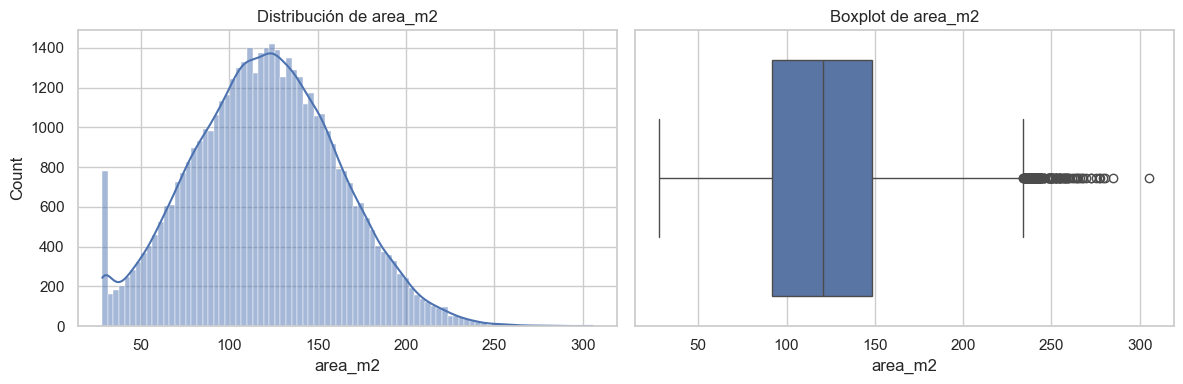

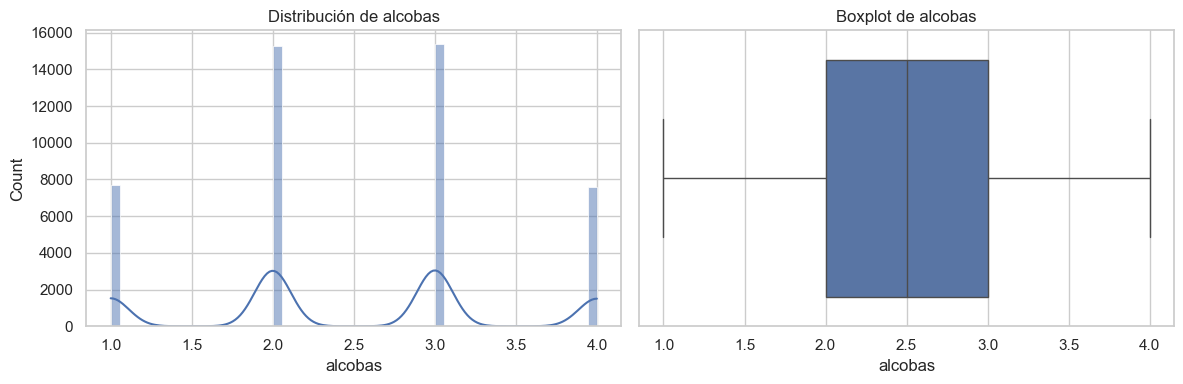

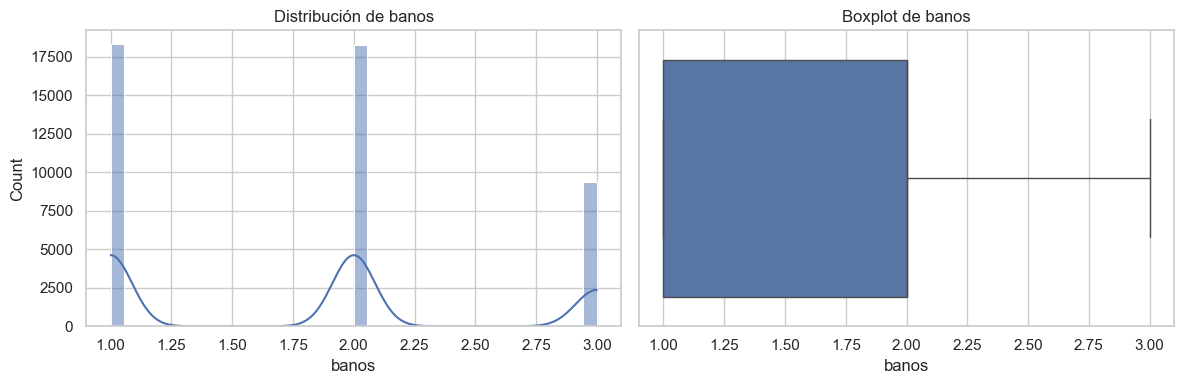

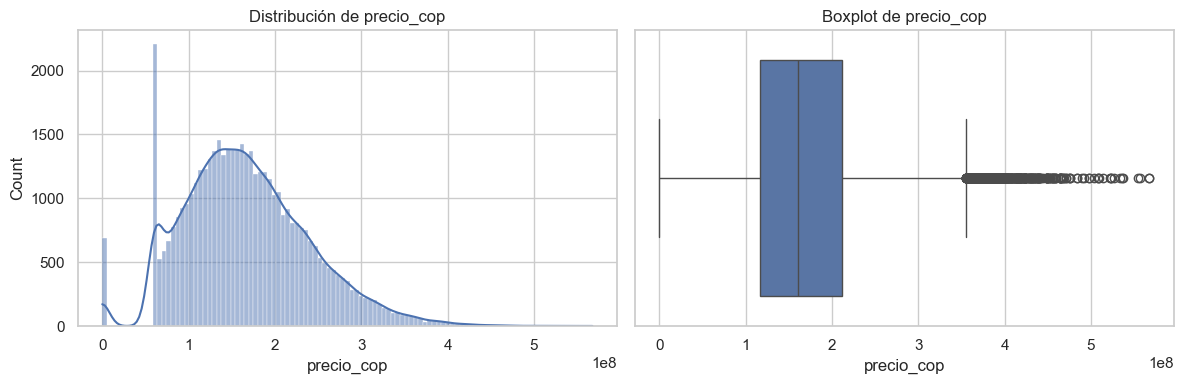

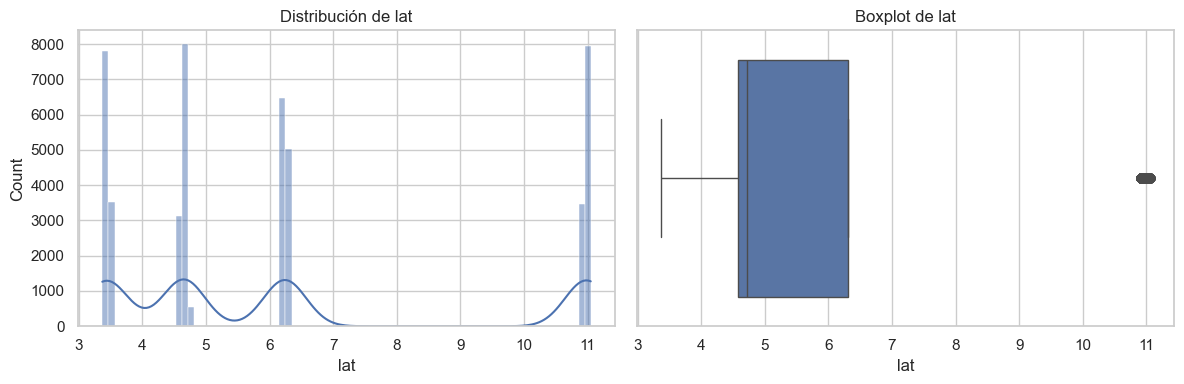

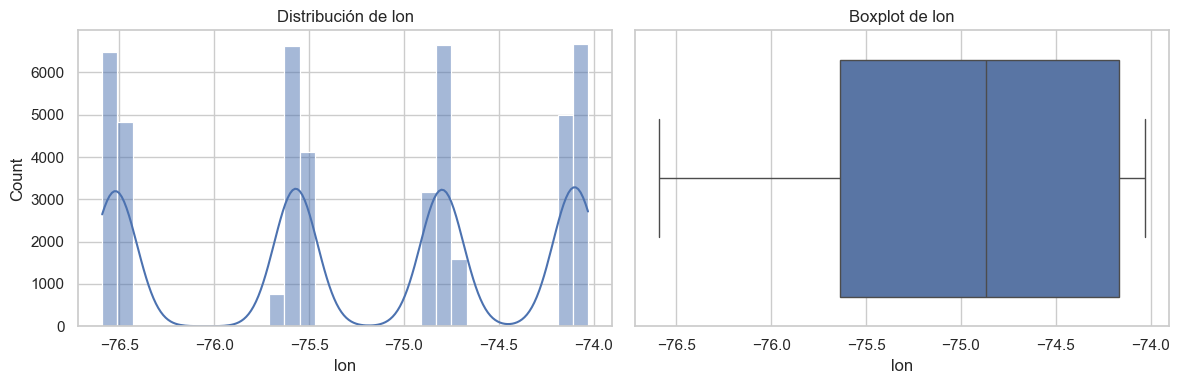

In [28]:
for column in numeric_columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df[column].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f'Distribución de {column}')

    sns.boxplot(x=df[column], ax=axes[1])
    axes[1].set_title(f'Boxplot de {column}')

    plt.tight_layout()
    plt.show()

## 8. Detección de outliers con IQR

In [29]:
def iqr_outlier_summary(dataframe: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    results = []

    for column in columns:
        series = dataframe[column].dropna()
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outlier_count = ((series < lower_bound) | (series > upper_bound)).sum()

        results.append({
            'column': column,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'outlier_count': outlier_count,
            'outlier_percentage': round(outlier_count / len(series) * 100, 2)
        })

    return pd.DataFrame(results).sort_values('outlier_count', ascending=False)

outlier_summary = iqr_outlier_summary(df, numeric_columns)
display(outlier_summary)

,column,lower_bound,upper_bound,outlier_count,outlier_percentage
4,lat,1.99,8.90,11419,24.88
3,precio_cop,"-27,400,000.00","355,000,000.00",612,1.34
0,area_m2,6.35,233.95,148,0.32
1,alcobas,0.50,4.50,0,0.00
2,banos,-0.50,3.50,0,0.00
5,lon,-77.84,-71.96,0,0.00


## 9. Análisis de variables categóricas

,count,percentage
id,,
CO016539,2,0.00
CO008254,2,0.00
CO029298,2,0.00
CO035703,2,0.00
CO036727,2,0.00
CO040807,2,0.00
CO021180,2,0.00
CO016351,2,0.00
CO027501,2,0.00


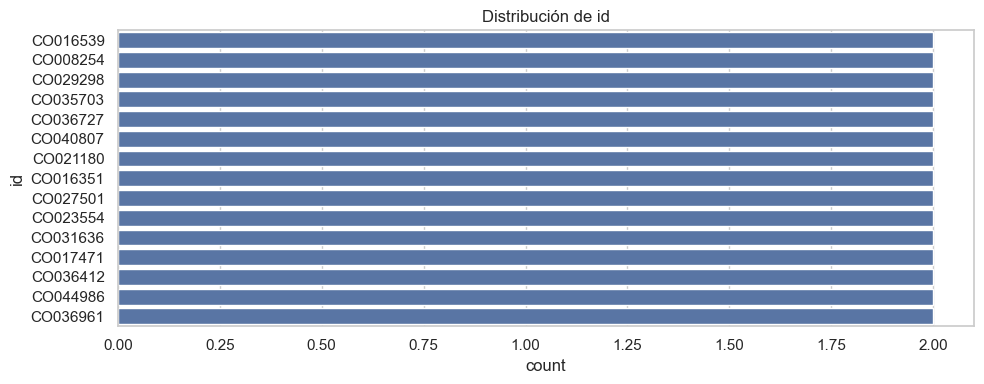

,count,percentage
ciudad,,
Santiago de Cali,5752,12.53
Barranquilla,5737,12.50
B/quilla,5682,12.38
Cali,5564,12.12
Medellin,3914,8.53
MEDELLIN,3806,8.29
Medellín,3795,8.27
Bogotá,2994,6.52
BOGOTA,2920,6.36


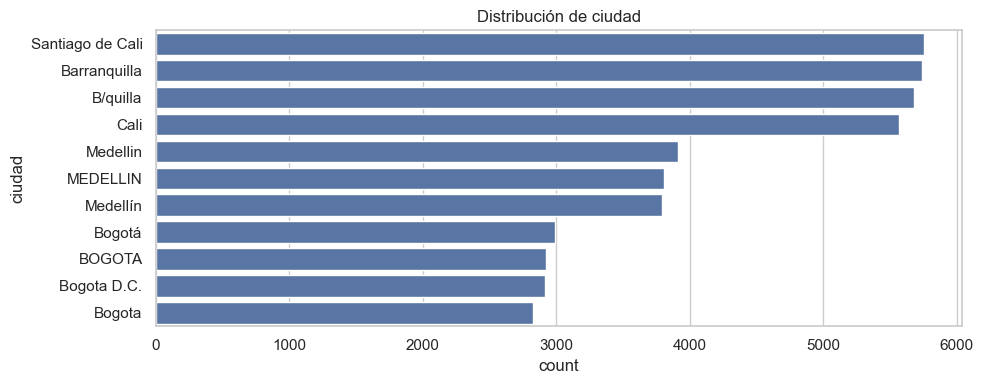

,count,percentage
tipo,,
Apartaestudio,11578,25.22
Casa,11450,24.95
Local,11442,24.93
Apartamento,11430,24.90


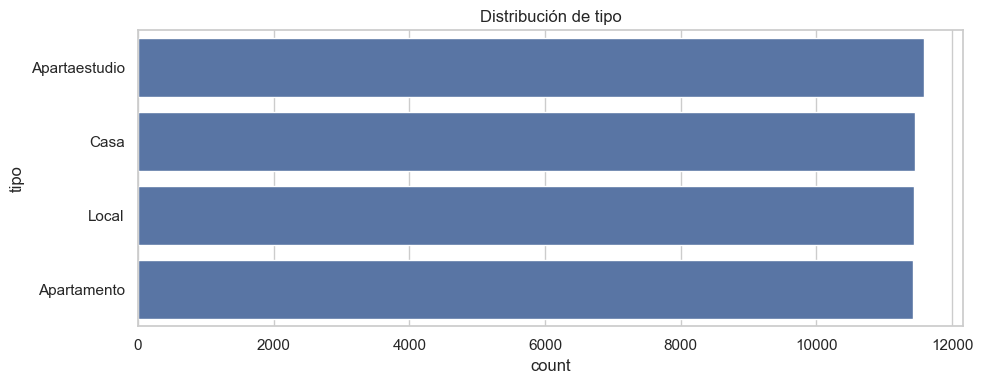

,count,percentage
fecha,,
2024-08-05,177,0.39
2024-05-17,172,0.37
2024-02-05,170,0.37
2024-12-04,166,0.36
2024-07-10,164,0.36
2024-02-08,162,0.35
2024-10-02,162,0.35
2024-04-07,162,0.35
2024-07-06,161,0.35


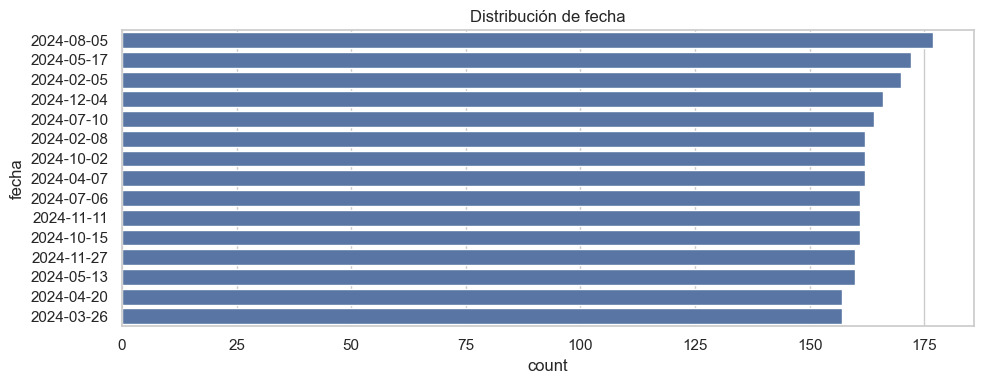

,count,percentage
estado,,
publicada,18274,39.81
vendida,11560,25.19
comprada,9228,20.10
remodelacion,6838,14.90


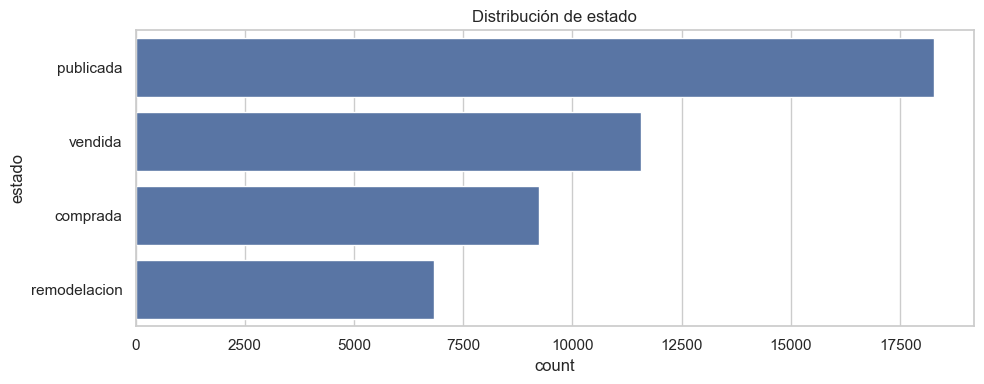

In [30]:
for column in categorical_columns:
    counts = df[column].astype(str).value_counts(dropna=False).head(15)

    display(
        pd.DataFrame({
            'count': counts,
            'percentage': (counts / len(df) * 100).round(2)
        })
    )

    plt.figure(figsize=(10, 4))
    sns.countplot(
        data=df,
        y=column,
        order=df[column].value_counts().head(15).index
    )
    plt.title(f'Distribución de {column}')
    plt.tight_layout()
    plt.show()

## 10. Correlaciones entre variables numéricas

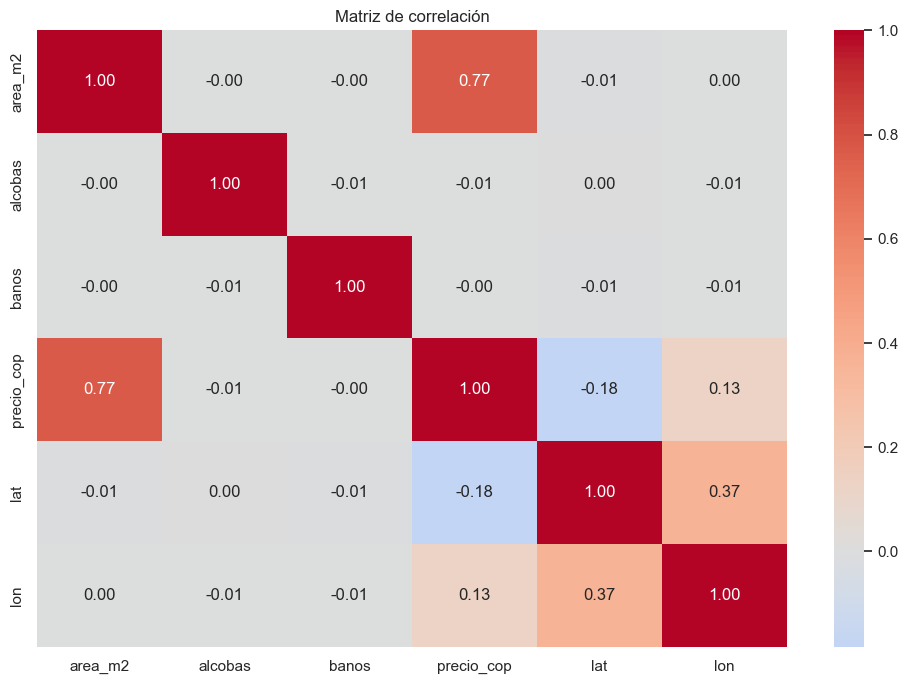

In [31]:
if len(numeric_columns) >= 2:
    correlation_matrix = df[numeric_columns].corr()

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0
    )
    plt.title('Matriz de correlación')
    plt.tight_layout()
    plt.show()
else:
    print('No hay suficientes variables numéricas para calcular correlaciones.')

## 11. Relaciones entre variables

In [ ]:
# Selecciona dos variables numéricas para analizar su relación.
X_VARIABLE = numeric_columns[0] if numeric_columns else None
Y_VARIABLE = numeric_columns[1] if len(numeric_columns) > 1 else None
HUE_VARIABLE = categorical_columns[0] if categorical_columns else None

if X_VARIABLE and Y_VARIABLE:
    plt.figure(figsize=(9, 5))
    sns.scatterplot(
        data=df,
        x=X_VARIABLE,
        y=Y_VARIABLE,
        hue=HUE_VARIABLE if HUE_VARIABLE else None,
        alpha=0.7
    )
    plt.title(f'{Y_VARIABLE} vs. {X_VARIABLE}')
    plt.tight_layout()
    plt.show()
else:
    print('Selecciona dos variables numéricas para crear el scatterplot.')

## 12. Análisis agrupado

Este ejemplo compara el promedio de una variable numérica entre categorías. Modifica las variables según el objetivo del análisis.

In [ ]:
if categorical_columns and numeric_columns:
    category = categorical_columns[0]
    metric = numeric_columns[0]

    grouped_analysis = (
        df.groupby(category, dropna=False)[metric]
        .agg(['count', 'mean', 'median', 'min', 'max'])
        .sort_values('mean', ascending=False)
    )

    display(grouped_analysis)
else:
    print('Se requiere al menos una variable categórica y una numérica.')

## 13. Conclusiones e insights

Completa esta sección después de revisar los resultados anteriores.

### Calidad de datos
- El dataset contiene **[número]** filas y **[número]** columnas.
- Las columnas con mayor porcentaje de valores nulos son **[columnas]**.
- Se encontraron **[número]** registros duplicados.

### Distribuciones
- La variable **[nombre]** presenta una distribución **[normal/sesgada/etc.]**.
- Se identificaron posibles outliers en **[columnas]**.

### Relaciones
- Existe una correlación **[positiva/negativa]** entre **[variable 1]** y **[variable 2]**.
- El grupo **[categoría]** presenta el mayor promedio de **[métrica]**.

### Próximos pasos
- Definir una estrategia para el tratamiento de valores nulos.
- Validar si los outliers corresponden a errores o casos legítimos.
- Crear variables derivadas cuando sea necesario.
- Preparar los datos para modelado, reporting o análisis posterior.

## 14. Exportación opcional del dataset procesado

In [ ]:
# Ejemplo:
# OUTPUT_PATH = Path('../data/processed_dataset.csv')
# df.to_csv(OUTPUT_PATH, index=False)
# print(f'Dataset exportado en: {OUTPUT_PATH.resolve()}')